<div align="center"><h1><b>Machine Learning-Based Classification of Heart Disease Risk for Insurance Decision Support Systems </b></h1></div>

---
<div align="center"><b>By : Prediksa Company (Group 13)</div>


### **Dataset Explanation**

The dataset is heart disease data obtained from Kaggle. The CSV-formatted data file named heart.csv contains 1025 patient observations and 13 predictor features, plus 1 target feature of heart disease status. All
features in this dataset are a combination of patient demographic data and clinical examination results, such as age, blood pressure, cholesterol levels, and electrocardiogram results.

The target feature is encoded as a binary variable with a value of 0
indicating no heart disease, and 1 indicating
an indication of heart disease.

**Source:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset/data

---

### **Dataset Column Description**

| Variable                    | Description                                                                                                                                           |
|------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `age`            | Patient's age                                                         |
| `sex`                       | Biological sex (0 = female, 1 = male)                                                                                                                                |
| `cp`                  | Type of chest pain (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)                                                                                                                                   |
| `trestbps`         | Resting blood pressure in mmHg                                                                                           |
| `chol`                 | Serum cholesterol level in mg/dl                                                                                                |
| `fbs`     | Fasting blood sugar status >120 mg/dl (0 = no, 1 = yes)                                                                                             |
| `restecg`             | ECG examination results at rest (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)                                                                                                                    |
| `thalach`           | Maximum heart rate achieved during the test                                                                                                                  |
| `exang`               | Presence of exercise-induced angina (0 = no, 1 = yes)                                                                                           |
| `oldpeak`      | ST-segment depression values due to physical activity compared to resting conditions                                                                                                              |
| `slope`       | ST segment slope at the peak of exercise (1: up, 2: flat, 3: down)                                                                                               |
| `ca`              | Number of major blood vessels visible through fluoroscopy (range 0-3)                  |
| `thal`| Thalassemia test results (3: normal, 6: permanent disability, 7: reversible disability)                                                                                               |
| `target`| Indications of heart disease (0: none, 1: present)                                   |

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, KFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import GaussianNB

## Load Dataset

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Exploratory Data Analysis

### 1. Descriptive Statistics 

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 2. Age distribution of heart disease patients (target == 1)

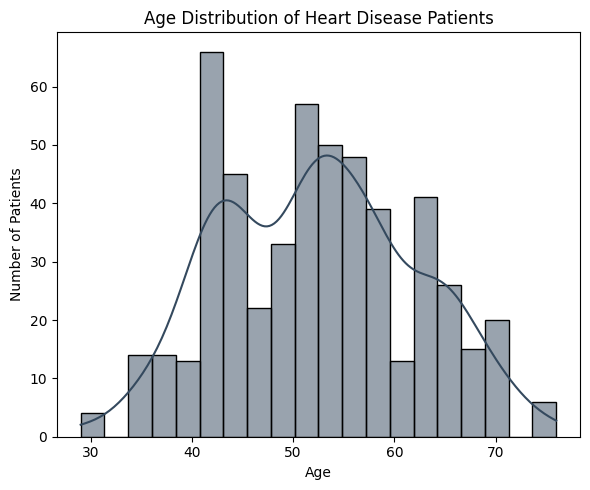

In [5]:
plt.figure(figsize=(6, 5))
sns.histplot(data=df[df['target'] == 1], x='age', bins=20, kde=True, color='#34495e')
plt.title('Age Distribution of Heart Disease Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.grid(False)
plt.tight_layout()
plt.show()

**Interpretation** : The chart shows that the number of patients with heart disease generally increases with age, peaking in their 50s. However, the highest number of individuals diagnosed with heart disease is actually in their 40s. This suggests that factors beyond age, such as lifestyle or health conditions, may play a significant role in the onset of heart disease.

### 3. Gender distribution of heart disease patients

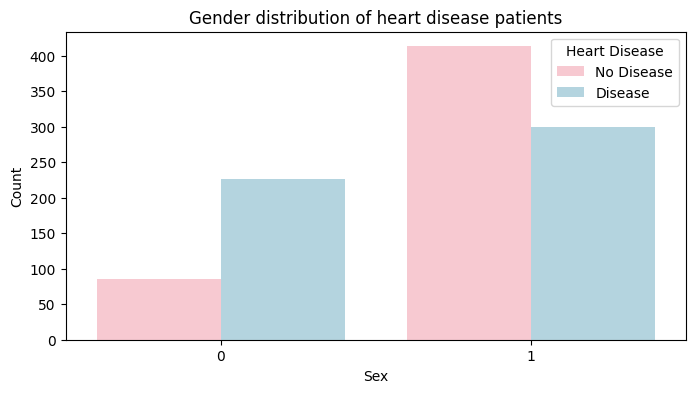

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(x='sex', hue='target', data=df, palette=['#ffc1cc', '#add8e6'])
plt.title('Gender distribution of heart disease patients')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.show()

**Interpretation** : Although the number of male patients is higher than female patients, the chart shows that both sexes have a significant proportion of heart disease cases. This highlights that while men may be more frequently diagnosed, women are also at considerable risk and should not be overlooked in risk assessments. This underlines the importance of heart disease screening for both males and females, regardless of overall prevalence.

### 4. Target Class 

In [7]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

Target data tends to be balanced

### 5. Target Class Distribution

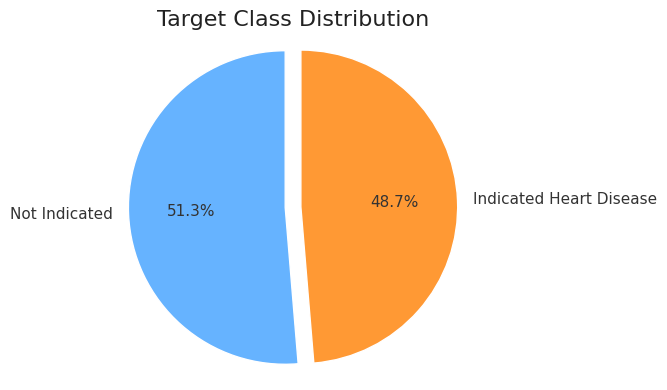

In [8]:
target_counts = df['target'].value_counts()
labels = ['Not Indicated', 'Indicated Heart Disease']
sizes = target_counts.values

colors = ['#66b3ff', '#ff9934']
explode = (0, 0.1)  # Highlight "Heart Disease" slice

plt.figure(figsize=(6, 4))
plt.pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    colors=colors, explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 11, 'weight': 'normal', 'color': '#333333'}
)

plt.title("Target Class Distribution", fontsize=16, weight='normal', color='#222222')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Interpretation** : This chart displays the number of patients diagnosed with and without heart disease.
It highlights the relative balance between these two groups in the dataset, which is important for building reliable predictive models.

### 6. Feature Correlation Heatmap

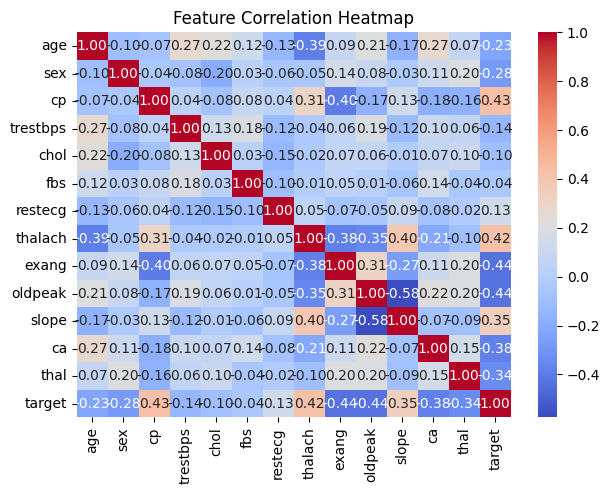

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation** : The heatmap displays the correlation matrix between feature variables and the target. The feature with the highest positive correlation to heart disease is thalach (maximum heart rate), with a value of 0.42, indicating that higher thalach values are associated with a greater risk of heart disease. Conversely, oldpeak (ST segment depression) has a negative correlation of -0.44 with the target, meaning that higher oldpeak values are linked to a lower risk of heart disease.

## Pre-Processing

### Check Missing value  

In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The data doesn't contain missing values

### Splitting Data

In [11]:
# Separate features (X) and targets (y)
X = df.drop(columns=['target'])
y = df['target']

# Split data into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling Data

In [12]:
# List of numeric features that need to be scaled
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Scaling of numerical features after split (avoid leakage)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

## Modelling

### Base Model

In [13]:
# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,                # limit depth
        min_samples_split=10,       # minimum samples for split
        min_samples_leaf=5,         # minimum samples per leaf
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=3,               # limit depth
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

In [14]:
# Calculate the cross validation accuracy of the model
cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv)
    mean_score = scores.mean()
    model_cv_scores[name] = mean_score
    print(f"{name} Mean CV Accuracy: {mean_score:.4f}")

Logistic Regression Mean CV Accuracy: 0.8549
Decision Tree Mean CV Accuracy: 0.8220
Random Forest Mean CV Accuracy: 0.8768
SVM Mean CV Accuracy: 0.8841
KNN Mean CV Accuracy: 0.8537


In [ ]:
# Select 3 best models based on cross validation score
top_models = sorted(model_cv_scores.items(), key=lambda x: x[1], reverse=True)[:3]
print("\n3 Best Models Based on Cross Validation Score:")
for name, score in top_models:
    print(f"{name}: {score:.4f}")


3 Best Models Based on Cross Validation Score:
SVM: 0.8841
Random Forest: 0.8768
Logistic Regression: 0.8549


In [16]:
# Confusion Matrix
print("\nEvaluation in Test Set:")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\nModel: {name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")



Evaluation in Test Set:

Model: Logistic Regression
Confusion Matrix:
[[73 29]
 [13 90]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

Accuracy: 0.7951

Model: Decision Tree
Confusion Matrix:
[[69 33]
 [12 91]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.68      0.75       102
           1       0.73      0.88      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205

Accuracy: 0.7805

Model: Random Forest
Confusion Matrix:
[[74 28]
 [14 89]]
Classification Report:
              precision    recall  

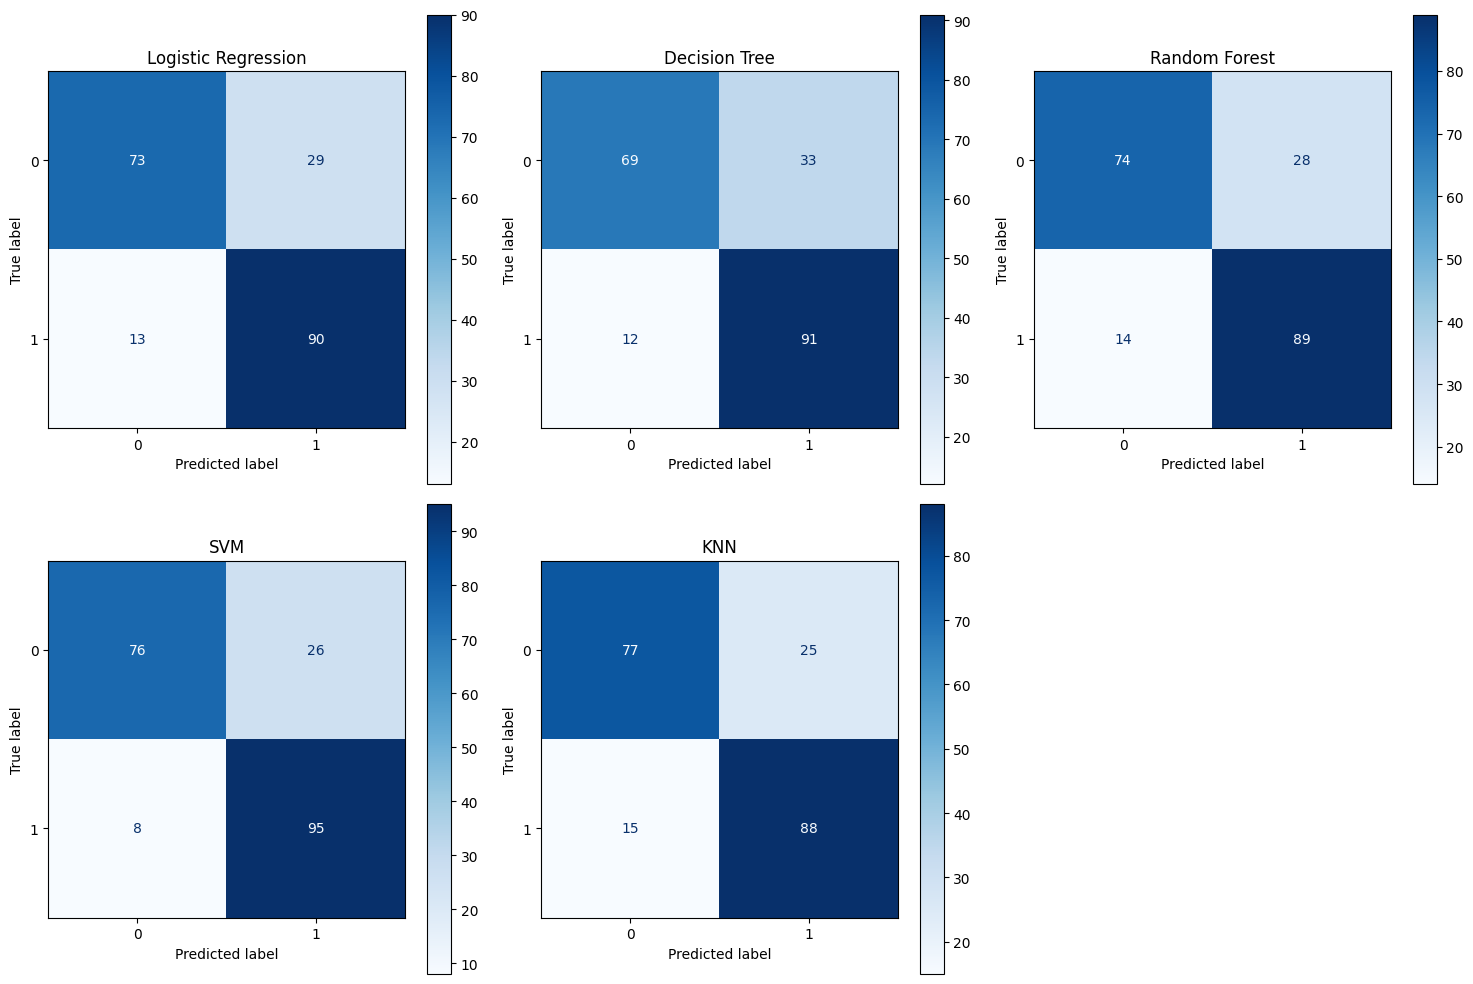

In [17]:
# Plot confusion matrix for each model
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    plt.subplot(2, 3, i)
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title(f"{name}")

plt.tight_layout()
plt.show()

## Ensamble model : Voting

In [18]:
# Take the best 3 models
top_model_objs = [(name, models[name]) for name, _ in top_models]

# Voting Classifier (use soft voting if the model supports probability)
voting_clf = VotingClassifier(estimators=top_model_objs, voting='soft', n_jobs=-1)  # atau 'hard'
voting_clf.fit(X_train_scaled, y_train)

# Prediction and evaluation
y_pred_voting = voting_clf.predict(X_test_scaled)
print("Voting Classifier:")
print(confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))
print(f"Akurasi: {accuracy_score(y_test, y_pred_voting):.4f}")

Voting Classifier:
[[73 29]
 [ 7 96]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       102
           1       0.77      0.93      0.84       103

    accuracy                           0.82       205
   macro avg       0.84      0.82      0.82       205
weighted avg       0.84      0.82      0.82       205

Akurasi: 0.8244


In [19]:
# Calculate the cross validation accuracy of the model
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(voting_clf, X_train_scaled, y_train, cv=cv)

# Evaluation results
print("Voting Classifier - Cross-Validation Scores:", scores)
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Voting Classifier - Cross-Validation Scores: [0.92073171 0.87804878 0.87804878 0.90853659 0.85365854]
Mean Accuracy: 0.8878
Standard Deviation: 0.0240


In [20]:
# Take the best 3 models
top_model_objs = [(name, models[name]) for name, _ in top_models]

# Voting Classifier (use hard voting if the model supports probability)
voting_clf = VotingClassifier(estimators=top_model_objs, voting='hard', n_jobs=-1)  # atau 'hard'
voting_clf.fit(X_train_scaled, y_train)

# Prediction and evaluation
y_pred_voting = voting_clf.predict(X_test_scaled)
print("Voting Classifier:")
print(confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))
print(f"Akurasi: {accuracy_score(y_test, y_pred_voting):.4f}")

Voting Classifier:
[[72 30]
 [ 7 96]]
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       102
           1       0.76      0.93      0.84       103

    accuracy                           0.82       205
   macro avg       0.84      0.82      0.82       205
weighted avg       0.84      0.82      0.82       205

Akurasi: 0.8195


In [21]:
# Calculate the cross validation accuracy of the model
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(voting_clf, X_train_scaled, y_train, cv=cv)

# Evaluation results
print("Voting Classifier - Cross-Validation Scores:", scores)
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")


Voting Classifier - Cross-Validation Scores: [0.92682927 0.87804878 0.86585366 0.90853659 0.83536585]
Mean Accuracy: 0.8829
Standard Deviation: 0.0321


## Ensamble model : Stacking

In [22]:
# Take the best 3 models
top_model_objs = [(name, models[name]) for name, _ in top_models]

# Meta-learner 
meta_learner = GaussianNB()

# Inisialisasi stacking classifier
stacking_clf = StackingClassifier(
    estimators=top_model_objs,
    final_estimator=meta_learner,
    passthrough=True  # True: base features + predictions masuk ke meta-learner
)

# Training model stacking
stacking_clf.fit(X_train_scaled, y_train)

# Prediction & Evaluation
y_pred_stack = stacking_clf.predict(X_test_scaled)

print("📊 [STACKING CLASSIFIER]")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("Classification Report:\n", classification_report(y_test, y_pred_stack))
print(f"Akurasi: {accuracy_score(y_test, y_pred_stack):.4f}")


📊 [STACKING CLASSIFIER]
Confusion Matrix:
 [[77 25]
 [10 93]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81       102
           1       0.79      0.90      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205

Akurasi: 0.8293


In [23]:
# Calculate the cross validation accuracy of the model
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=cv)

print(f"Mean CV Accuracy (Stacking): {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Mean CV Accuracy (Stacking): 0.8854
Std Dev: 0.0242
